In [18]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.manifold import TSNE
import plotly.express as px
import matplotlib.pyplot as plt

# Load Data

In [3]:
db_path = Path("../../data/database.sqlite")
conn = sqlite3.connect(db_path.as_posix())
df_player = pd.read_sql_query("SELECT * FROM Player_Cleaned", conn)
conn.close()

In [4]:
df_player_rating_gte_85 = df_player[df_player["overall_rating"] >= 85]
df_player_rating_gte_85.shape

(1703, 45)

In [5]:
df_player_rating_gte_85_unique = df_player_rating_gte_85.drop_duplicates(
    subset=["player_name"]
)
df_player_rating_gte_85_unique.shape

(227, 45)

In [6]:
player_stats_cols = [
    "preferred_foot",
    "attacking_work_rate",
    "defensive_work_rate",
    "crossing",
    "finishing",
    "heading_accuracy",
    "short_passing",
    "volleys",
    "dribbling",
    "curve",
    "free_kick_accuracy",
    "long_passing",
    "ball_control",
    "acceleration",
    "sprint_speed",
    "agility",
    "reactions",
    "balance",
    "shot_power",
    "jumping",
    "stamina",
    "strength",
    "long_shots",
    "aggression",
    "interceptions",
    "positioning",
    "vision",
    "penalties",
    "marking",
    "standing_tackle",
    "sliding_tackle",
]

In [7]:
df_player_rating_gte_85_unique[player_stats_cols].head()

,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,...,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle
2952,0.0,1.0,0.0,92.0,88.0,78.0,80.0,80.0,83.0,85.0,...,78.0,84.0,63.0,36.0,84.0,82.0,94.0,21.0,30.0,28.0
3240,1.0,1.0,0.0,53.0,86.0,84.0,64.0,78.0,84.0,70.0,...,95.0,81.0,77.0,87.0,84.0,78.0,86.0,20.0,20.0,20.0
4908,0.0,1.0,0.0,64.0,91.0,87.0,68.0,84.0,85.0,73.0,...,65.0,83.0,62.0,78.0,78.0,78.0,71.0,22.0,31.0,22.0
6198,0.0,1.0,0.0,83.0,88.0,64.0,92.0,87.0,92.0,88.0,...,68.0,88.0,70.0,88.0,90.0,90.0,91.0,26.0,36.0,32.0
6508,0.0,1.0,2.0,36.0,22.0,78.0,68.0,37.0,54.0,46.0,...,78.0,34.0,78.0,92.0,37.0,55.0,42.0,88.0,90.0,90.0


# Compute Embeddings

In [8]:
class PositionTower(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=2, out_features=64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Linear(in_features=64, out_features=128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Linear(in_features=128, out_features=64),
        )

    def forward(self, x):
        return self.net(x)


class PlayerTower(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(31),
            nn.Linear(in_features=31, out_features=128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Linear(in_features=128, out_features=128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Linear(in_features=128, out_features=64),
        )

    def forward(self, x):
        return self.net(x)


class SimpleTwoTower(nn.Module):
    def __init__(self):
        super().__init__()
        self.position_tower = PositionTower()
        self.player_tower = PlayerTower()

    def forward(self, position, player):
        pos_emb = self.position_tower(position)
        plr_emb = self.player_tower(player)

        p_norm = pos_emb / (torch.linalg.norm(pos_emb, dim=1, keepdim=True) + 1e-8)
        u_norm = plr_emb / (torch.linalg.norm(plr_emb, dim=1, keepdim=True) + 1e-8)

        return p_norm, u_norm

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the Simple Model
model = SimpleTwoTower().to(device)
model_path = "simple_soccer_model.pth"  # Ensure you saved the simple model here
state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [10]:
def compute_player_embeddings(
    player_df,
    model,
    device,
    player_stats_cols,
):
    """
    Computes normalized player embeddings for all players in the dataframe.

    Returns
    -------
    DataFrame
        index: player_name
        columns: emb_1 ... emb_64
    """

    model.eval()

    # -------------------------
    # 1. Extract player stats
    # -------------------------
    player_stats = player_df[player_stats_cols].values

    player_tensor = torch.tensor(player_stats, dtype=torch.float32).to(device)

    # -------------------------
    # 2. Forward pass
    # -------------------------
    with torch.no_grad():
        player_emb = model.player_tower(player_tensor)

        # Same normalization used in training
        player_norm = player_emb / (
            torch.linalg.norm(player_emb, dim=1, keepdim=True) + 1e-8
        )

    player_embeddings = player_norm.cpu().numpy()

    # -------------------------
    # 3. Create dataframe
    # -------------------------
    emb_cols = [f"emb_{i + 1}" for i in range(player_embeddings.shape[1])]

    df_embeddings = pd.DataFrame(
        player_embeddings,
        index=player_df["player_name"].values,
        columns=emb_cols,
    )

    return df_embeddings

In [11]:
df_player_embeddings = compute_player_embeddings(
    df_player_rating_gte_85_unique,
    model,
    device,
    player_stats_cols,
)

print(df_player_embeddings.shape)

(227, 64)


In [13]:
df_player_embeddings.head()

,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,...,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63,emb_64
Adrian Mutu,-0.020582,-0.105221,0.235253,-0.160245,-0.000877,-0.062778,-0.017771,0.106232,-0.090143,-0.037608,...,-0.027775,0.121756,-0.039588,0.144639,0.100600,-0.146436,-0.170151,0.061572,0.114620,0.214116
Adriano,-0.111048,-0.103640,0.189767,-0.151643,-0.054903,-0.070740,0.078390,0.043154,-0.110959,-0.040364,...,0.004507,0.075201,0.007192,0.131017,0.098600,-0.061518,-0.184357,-0.064227,0.080438,0.192515
Alberto Gilardino,-0.059089,-0.087288,0.219679,-0.085820,-0.057834,-0.035812,0.005653,0.156332,-0.087458,-0.029002,...,-0.035107,0.084488,-0.049457,0.160859,0.094415,-0.154326,-0.197009,-0.043287,0.105948,0.184393
Alessandro Del Piero,-0.070235,-0.088953,0.262078,0.012089,-0.032291,-0.047141,0.045892,0.236555,-0.072045,-0.044363,...,-0.026210,0.090476,-0.028654,0.139292,0.106001,-0.185851,-0.208666,-0.055549,0.102720,0.211339
Alessandro Nesta,-0.118927,-0.049154,0.224535,0.137279,-0.013175,-0.015564,0.357025,-0.211691,-0.154426,0.041149,...,0.107401,-0.086796,0.136812,-0.166292,0.039195,-0.001638,-0.035712,-0.139700,-0.202052,0.203534


# Dimensionality Reduction

In [ ]:
def visualize_player_embeddings_tsne(df_player_embeddings):
    """
    Performs t-SNE dimensionality reduction on player embeddings
    and visualizes them in a 2D scatter plot.

    Parameters
    ----------
    df_player_embeddings : DataFrame
        index = player_name
        columns = embedding dimensions (emb_1 ... emb_64)
    """

    player_names = df_player_embeddings.index
    embeddings = df_player_embeddings.values

    # -----------------------
    # t-SNE dimensionality reduction
    # -----------------------
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=42,
    )

    embeddings_2d = tsne.fit_transform(embeddings)

    df_plot = pd.DataFrame(
        {
            "player_name": player_names,
            "tsne_x": embeddings_2d[:, 0],
            "tsne_y": embeddings_2d[:, 1],
        }
    )

    # -----------------------
    # Visualization
    # -----------------------
    fig = px.scatter(
        df_plot,
        x="tsne_x",
        y="tsne_y",
        hover_name="player_name",
        title="t-SNE Projection of Player Embeddings",
    )

    fig.update_traces(marker=dict(size=8, opacity=0.8))

    fig.update_layout(
        width=900,
        height=700,
        template="plotly_white",
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
    )

    fig.show()

    return df_plot

In [17]:
df_tsne = visualize_player_embeddings_tsne(df_player_embeddings)

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


def plot_tsne_with_selected_players(
    df_player_embeddings, highlight_players, figsize=(10, 8), random_state=42
):
    """
    Plot t-SNE projection of player embeddings.

    All players: grey dots
    Selected players: red dots + labels
    """

    player_names = df_player_embeddings.index.values
    embeddings = df_player_embeddings.values

    # -------------------------
    # t-SNE reduction
    # -------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=random_state,
    )

    emb_2d = tsne.fit_transform(embeddings)

    # -------------------------
    # Plot base layer (all players)
    # -------------------------
    plt.figure(figsize=figsize)

    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=40, color="grey", alpha=0.6)

    # -------------------------
    # Highlight specific players
    # -------------------------
    for i, name in enumerate(player_names):
        if name in highlight_players:
            x, y = emb_2d[i]

            plt.scatter(x, y, s=120, color="red")

            plt.text(x + 0.4, y + 0.4, name, fontsize=15)

    plt.title("t-SNE Projection of Player Embeddings")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")

    plt.tight_layout()
    plt.show()

    return emb_2d

In [39]:
highlight_players = [
    "Robert Lewandowski",
    "Dimitar Berbatov",
    "Karim Benzema",
    "Cristiano Ronaldo",
    "Lionel Messi",
    "Zlatan Ibrahimovic",
    "Neymar",
    "Kevin De Bruyne",
    "Steven Gerrad",
    "David Beckham",
    "Sergio Busquets",
    "Philipp Lahm",
    "Sergio Ramos",
    "Rio Ferdinand",
    "Giorgio Chiellini",
    "Daniel van Buyten",
    "Manuel Neuer",
    "Gianluigi Buffon",
    "Edwin van der Saar",
]

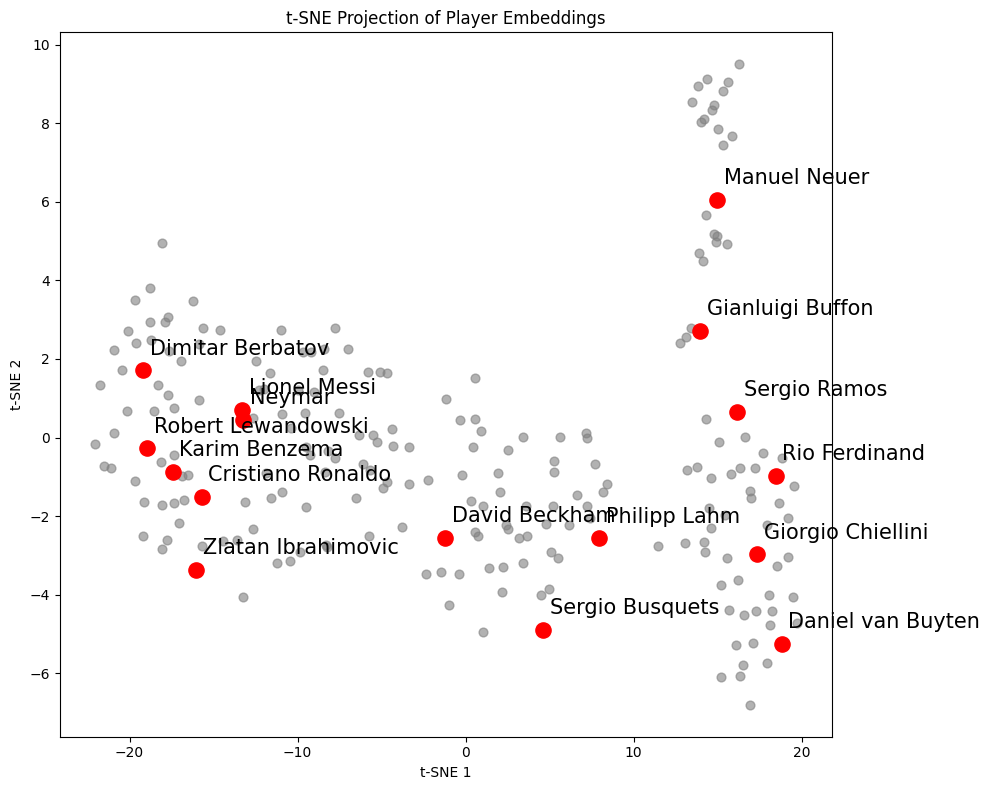

In [41]:
df_mpl = plot_tsne_with_selected_players(
    df_player_embeddings, highlight_players=highlight_players
)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


def plot_tsne_kmeans_with_selected_players(
    df_player_embeddings,
    highlight_players,
    figsize=(10, 8),
    random_state=42,
):
    """
    t-SNE projection + KMeans clustering.

    - Points colored by cluster
    - Highlighted players have larger markers + red border + labels
    """

    player_names = df_player_embeddings.index.values
    embeddings = df_player_embeddings.values

    # -------------------------
    # t-SNE reduction
    # -------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=random_state,
    )

    emb_2d = tsne.fit_transform(embeddings)

    # -------------------------
    # KMeans clustering (4 clusters)
    # -------------------------
    kmeans = KMeans(n_clusters=4, random_state=random_state, n_init="auto")
    cluster_labels = kmeans.fit_predict(embeddings)

    # Colors (none red)
    cluster_colors = ["tab:blue", "tab:green", "tab:orange", "tab:purple"]

    # -------------------------
    # Plot base layer
    # -------------------------
    plt.figure(figsize=figsize)

    for cluster_id in range(4):
        mask = cluster_labels == cluster_id

        plt.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            s=40,
            color=cluster_colors[cluster_id],
            alpha=0.7,
        )

    # -------------------------
    # Highlight specific players
    # -------------------------
    for i, name in enumerate(player_names):
        if name in highlight_players:
            x, y = emb_2d[i]

            plt.scatter(
                x,
                y,
                s=180,
                color=cluster_colors[cluster_labels[i]],
                edgecolor="red",
                linewidth=2,
                zorder=3,
            )

            plt.text(
                x + 0.4,
                y + 0.4,
                name,
                fontsize=15,
                zorder=4,
            )

    plt.title("t-SNE Projection of Player Embeddings (KMeans Clusters)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")

    plt.tight_layout()
    plt.show()

    return emb_2d, cluster_labels

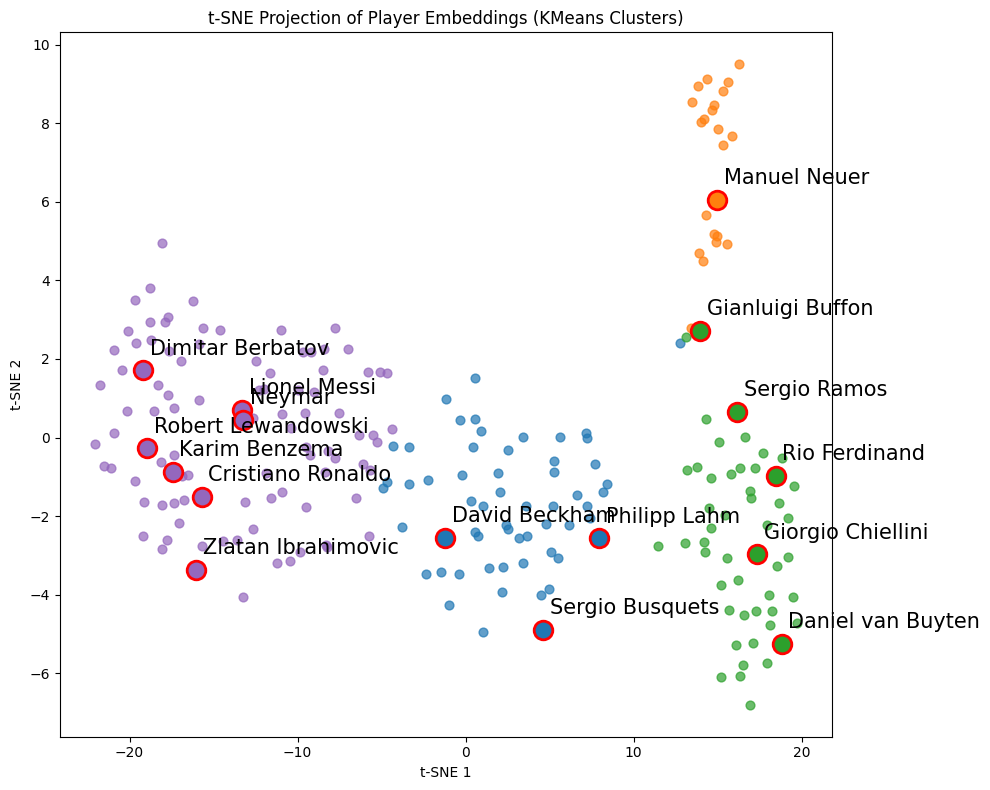

In [ ]:
emb_2d, clusters = plot_tsne_kmeans_with_selected_players(
    df_player_embeddings, highlight_players
)